In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# let load the data
car_df = pd.read_csv('car_price_dataset_medium.csv')
car_df.head()

,Car_ID,Brand,Model_Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Engine_CC,Max_Power_bhp,Mileage_kmpl,Seats,Price_USD
0,1,Audi,2005,197018,Diesel,Manual,First,4046,223.6,29.61,6,119611.94
1,2,BMW,2019,43467,Hybrid,Automatic,First,3731,248.4,21.66,5,90842.46
2,3,Kia,2012,153697,Hybrid,Automatic,Third,4925,465.5,12.14,6,78432.24
3,4,Mercedes,2015,38893,Petrol,Automatic,Second,3771,229.7,19.65,6,44568.89
4,5,Audi,2016,81329,Hybrid,Automatic,First,2817,573.2,7.74,5,8751.82


In [7]:
car_df.Brand.value_counts()

Brand
Toyota        118
Ford          110
Mercedes      107
Volkswagen    107
Kia           100
Hyundai        96
Audi           94
BMW            94
Nissan         91
Honda          83
Name: count, dtype: int64

<Axes: xlabel='Brand'>

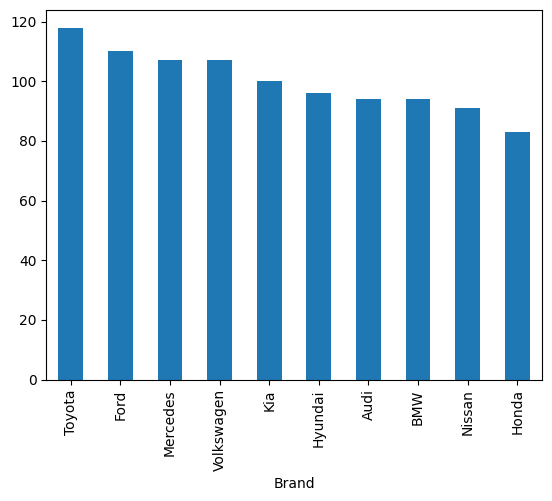

In [6]:
# lets do the basic analysis of the data
car_df.Brand.value_counts().plot(kind='bar')

In [9]:
car_df.rename(columns={'Price_USD':'Price'}, inplace=True)

<Axes: ylabel='Brand'>

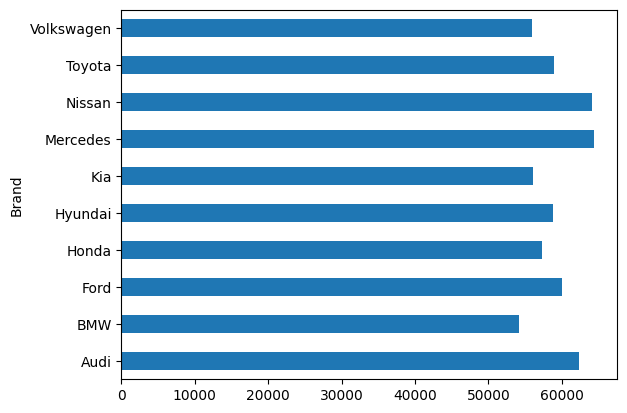

In [10]:
# what is average price of car based on brand
car_df.groupby('Brand')['Price'].mean().plot(kind='barh')

In [17]:
order=car_df['Brand'].value_counts(normalize=True)
order

Brand
Toyota        0.118
Ford          0.110
Mercedes      0.107
Volkswagen    0.107
Kia           0.100
Hyundai       0.096
Audi          0.094
BMW           0.094
Nissan        0.091
Honda         0.083
Name: proportion, dtype: float64

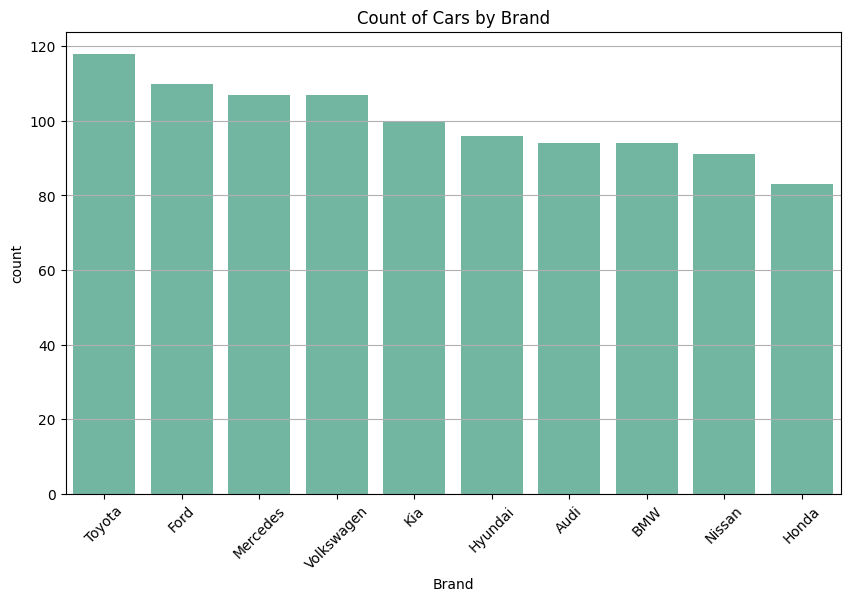

In [18]:
# let utilize seaborn/matplotlib for better visualization
plt.figure(figsize=(10,6))
sns.countplot(data=car_df, x='Brand', order=car_df['Brand'].value_counts(normalize=True).index) # as %page
# lets change the color palette
sns.set_palette('Set2')

plt.title('Count of Cars by Brand')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

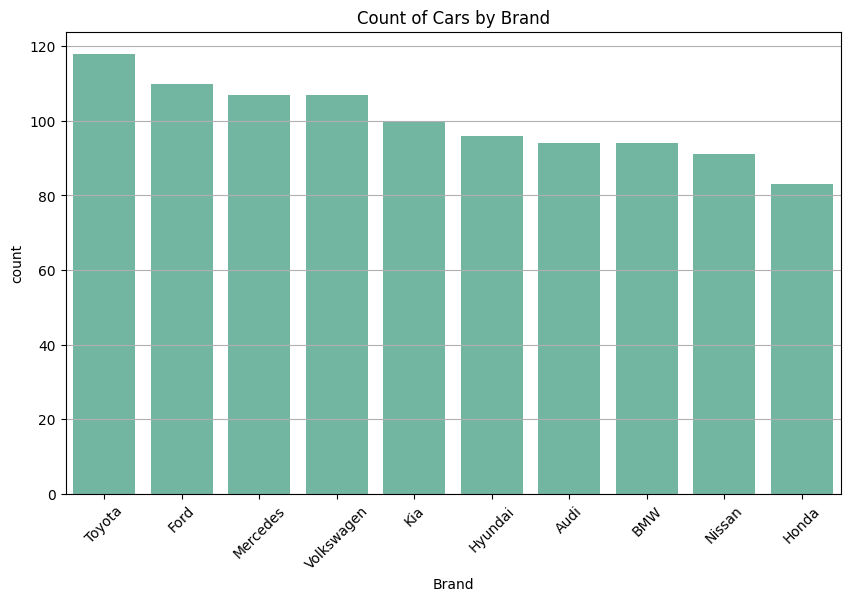

In [20]:
# here lets show the same as percentage of total

plt.figure(figsize=(10,6))
sns.countplot(data=car_df, x='Brand', order=car_df['Brand'].value_counts(normalize=True).index) # as %page
# lets change the color palette
sns.set_palette('Set2')

plt.title('Count of Cars by Brand')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

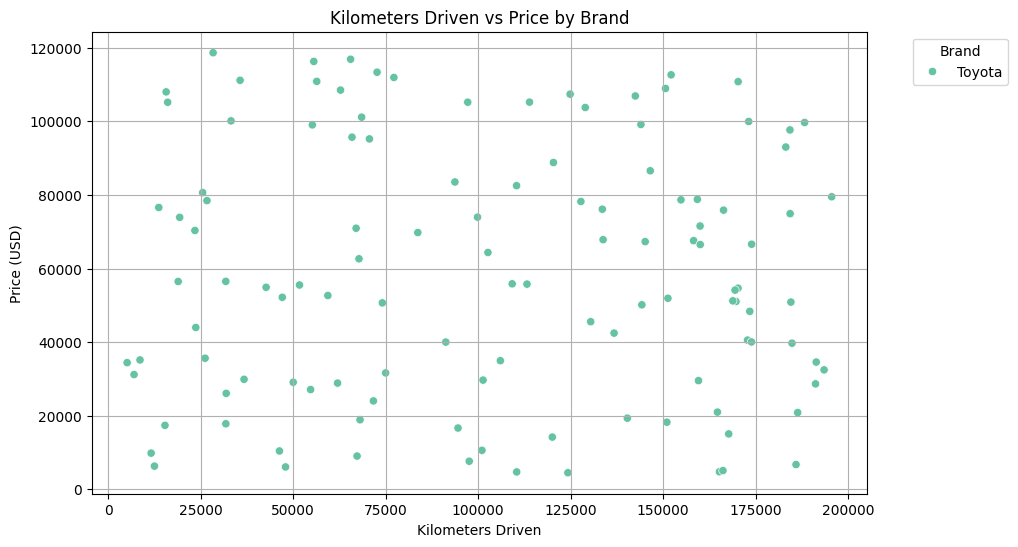

In [ ]:
car_df.head(5)

# Kilometers_Driven vs Price
plt.figure(figsize=(10,6))
sns.scatterplot(data=car_df[car_df['Brand'] == 'Toyota'], x='Kilometers_Driven', y='Price', hue='Brand')
plt.title('Kilometers Driven vs Price by Brand')
plt.xlabel('Kilometers Driven')
plt.ylabel('Price (USD)')
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()



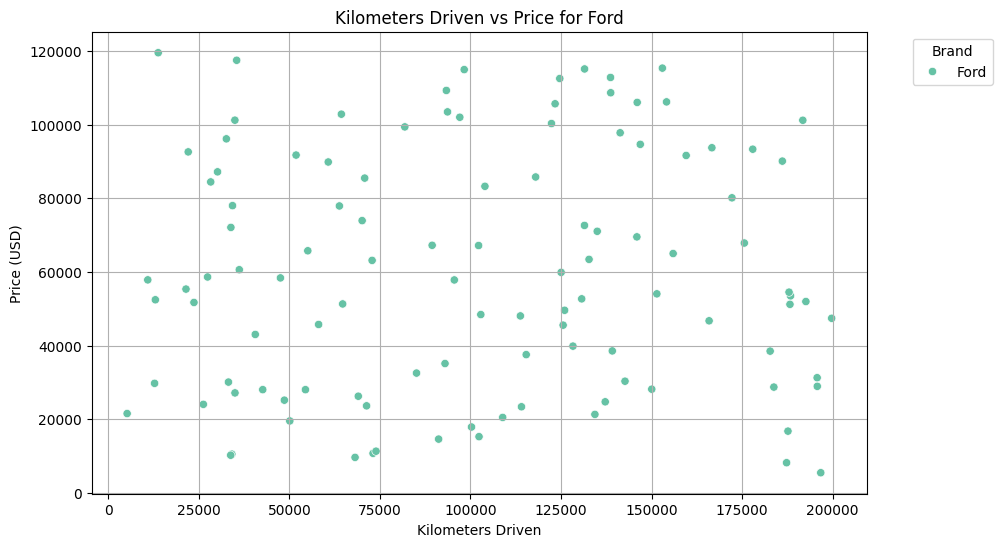

In [25]:
def brand_price_scatter(brand_name):
    plt.figure(figsize=(10,6))
    sns.scatterplot(data=car_df[car_df['Brand'] == brand_name], x='Kilometers_Driven', y='Price', hue='Brand')
    plt.title(f'Kilometers Driven vs Price for {brand_name}')
    plt.xlabel('Kilometers Driven')
    plt.ylabel('Price (USD)')
    plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid()
    plt.show()

brand_price_scatter('Ford')

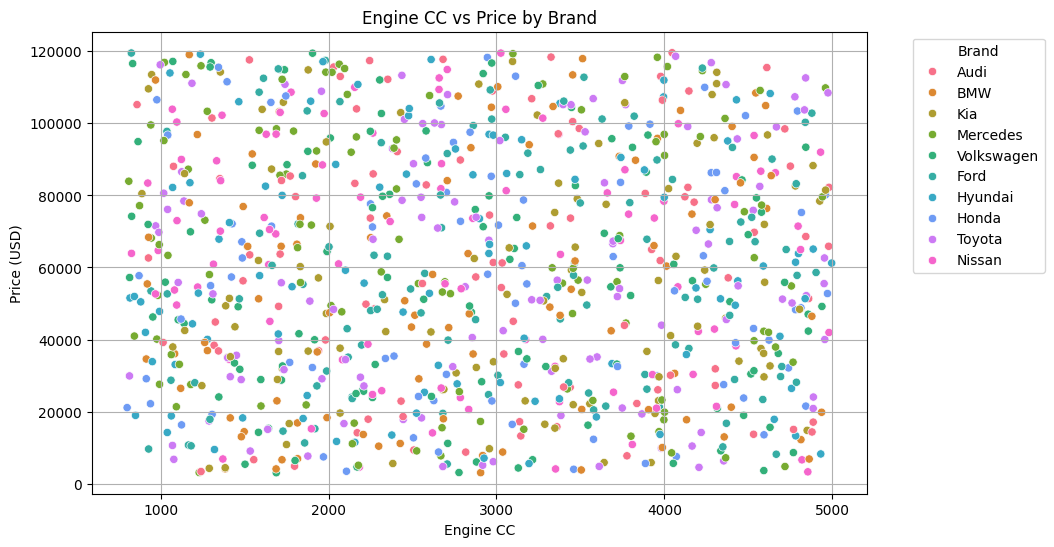

In [ ]:
# Engine_CC vs Price
plt.figure(figsize=(10,6))
sns.scatterplot(data=car_df, x='Engine_CC', y='Price', hue='Brand')
plt.title('Engine CC vs Price by Brand')
plt.xlabel('Engine CC')
plt.ylabel('Price (USD)')
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
# plt.show()

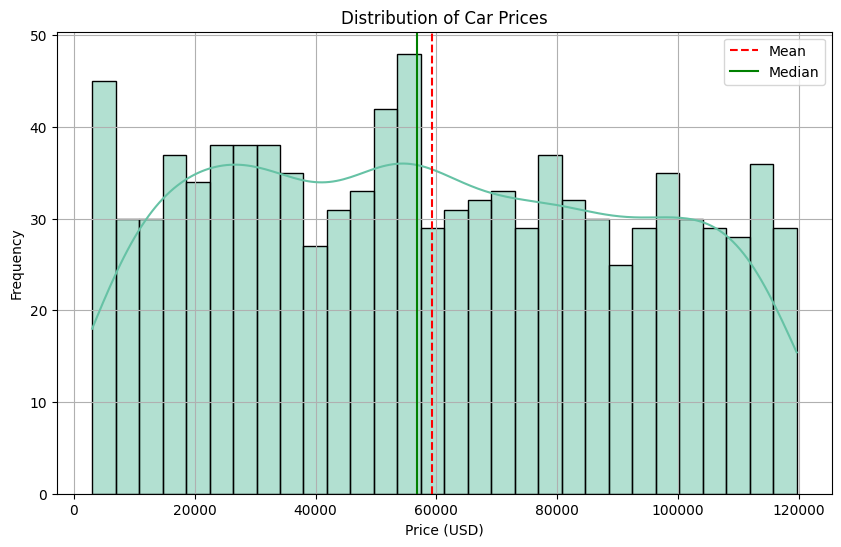

In [35]:
# plot histogram of Price along with mean and median lines
plt.figure(figsize=(10,6))
sns.histplot(data=car_df, x='Price', bins=30, kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')

# Calculate and plot mean and median lines
mean_price = car_df['Price'].mean()
median_price = car_df['Price'].median()
plt.axvline(mean_price, color='r', linestyle='--', label='Mean')
plt.axvline(median_price, color='g', linestyle='-', label='Median')
plt.legend()

plt.grid()
plt.show()

In [38]:
car_df.head(2)

,Car_ID,Brand,Model_Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Engine_CC,Max_Power_bhp,Mileage_kmpl,Seats,Price
0,1,Audi,2005,197018,Diesel,Manual,First,4046,223.6,29.61,6,119611.94
1,2,BMW,2019,43467,Hybrid,Automatic,First,3731,248.4,21.66,5,90842.46


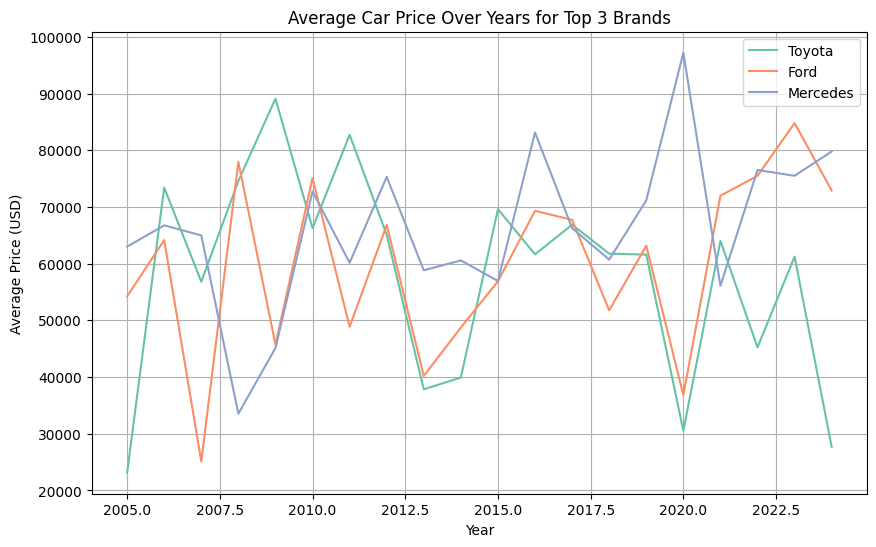

In [39]:
#  lets plot line plot of average price over the years for top 3 brands
top_brands = car_df['Brand'].value_counts().nlargest(3).index   
plt.figure(figsize=(10,6))
for brand in top_brands:
    brand_data = car_df[car_df['Brand'] == brand]
    avg_price_per_year = brand_data.groupby('Model_Year')['Price'].mean().reset_index()
    sns.lineplot(data=avg_price_per_year, x='Model_Year', y='Price', label=brand) 
plt.title('Average Car Price Over Years for Top 3 Brands')
plt.xlabel('Year')
plt.ylabel('Average Price (USD)')
plt.legend()
plt.grid()
plt.show()

In [41]:
car_df.shape

(1000, 12)

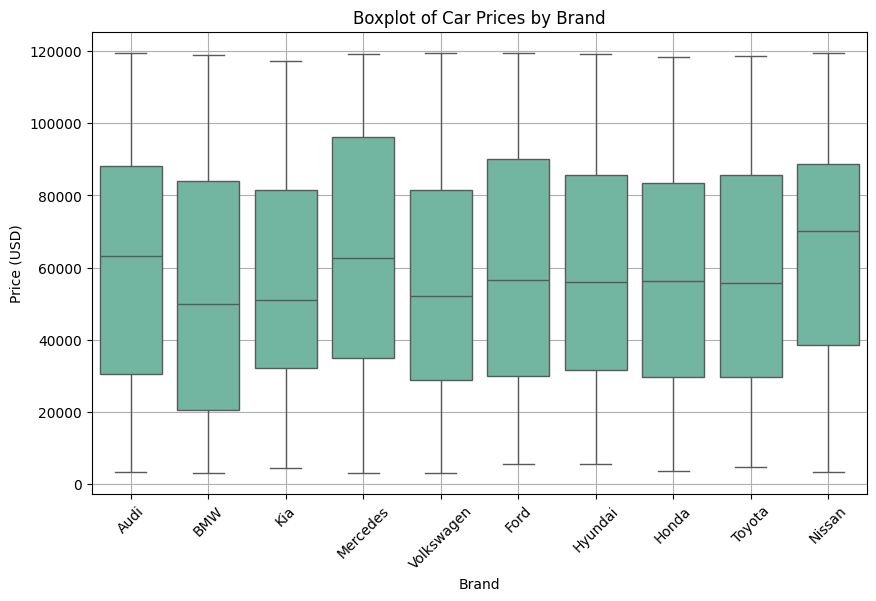

In [42]:
# list of plot in seaborn
# categorial plots: catplot, boxplot, violinplot, stripplot, swarmplot
# distribution plots: histplot, kdeplot, ecdfplot
# relational plots: scatterplot, lineplot
# regression plots: regplot, lmplot


# categorial plot example
plt.figure(figsize=(10,6))
sns.boxplot(data=car_df, x='Brand', y='Price')
plt.title('Boxplot of Car Prices by Brand')
plt.xlabel('Brand')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.grid()
plt.show()